<a href="https://colab.research.google.com/github/peony1217-ctrl/Warp_up_first/blob/main/%ED%86%B5%EC%8B%A0_%EB%8C%80%EC%9E%A5%EC%A3%BC_%EC%A3%BC%EA%B0%80%EC%98%88%EC%B8%A1_Wrapup_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# **프로젝트 소개**

# 지금까지 배운 파이썬을 이용하여, 국내 통신 섹터 대장주 2개를 선정하여 과거의 주가를 분석하고, 적절한 주가 예측 모델 만들어보기

# **배경**

# - 국내 통신 산업의 대장주에 대한 투자 관심 - 안정적 배당과 시장 점유율로 경기변동에 민감하지 않음
# - 주식 시장 변동성 확대 - 단순 과거 데이터만 보는 것이 아니라 추세와 패턴 기반 분석이 필요
# - 통신주는 경비 비민감주라, 거시경제의 충격에도 변동성이 적고, 이벤트성 사건 같은 비정상적 이벤트에서만 순간적 영향을 받는 경우가 있어, 최근 해킹 이슈 같은 특정 날짜의 사건이 주가에 통계적으로 유의한 영향을 미쳤는지 확인
# - 데이터 기반 의사결정 필요성 - 최근 과거 주가 데이터를 활용한 시계열 분석 및 기술적 지표 활용 & 단순 시각화뿐 아니라, 예측 모델을 통해 미래 가격 방향성을 가늠

# **목적**

# - 주가 데이터 분석 - 2025년 1월부터 9월까지 SKT/KT 일별 주가 데이터를 수집하고, 일별 수익률, 상승/하락일 통계, 히스토그램, 이동평균 등 기본 통계와 시각화
# - 기술적 분석 지표 활용 - 단기(20일)와 중기(50일) 이동평균 교차를 통해 매수/매도 시그널 도출
# - 단기 주가 예측 - ARIMA 모델을 활용하여 30일 단기 예측 수행 - 이동평균 교차, 일별 수익률과 결합하여 단기 투자 전략 참고
# - 투자 의사결정 지원 - 분석 결과를 기반으로, 투자자는 단기 가격 추세와 변동성을 시각적으로 확인 / 단기 매매 전략 또는 포트폴리오 조정 판단에 활용 가능

# **개발 환경**

# - 언어 : Python
# - 라이브러리 : Pandas, FinanceDataReader, matplotlib, seaborn

# **데이터 검색, 수집 및 저장**

# 네이버 증권 : https://finance.naver.com/

# → 업종별-통신으로 검색 → 시가총액 순으로 정렬하여 시가총액, 거래량, PER, 배당수익률 등 확인하여 대장주 선정

# 한국거래소 : https://www.krx.co.kr/main/main.jsp

# → 2024년 1월 1일 부터 2024년 12월 31일 일자별 시세를 csv 파일로 다운로드

# **분석대상설정**

# 국내 통신 대장주를 시가총액 별로 확인하여 2개를 선정



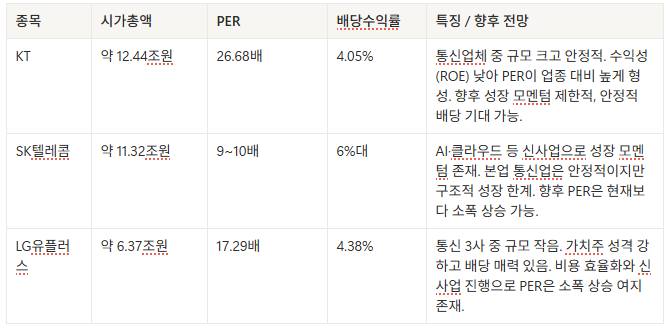

SKT 데이터


,Open,High,Low,Close,Volume,Change
Date,,,,,,
2025-01-02,55100,56200,55000,56100,356158,0.016304
2025-01-03,56600,57000,56300,56700,387268,0.010695
2025-01-06,56600,56800,55200,55600,602146,-0.019400
2025-01-07,55600,56200,55500,55800,536013,0.003597
2025-01-08,55400,56300,55300,56100,394975,0.005376


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 183 entries, 2025-01-02 to 2025-09-30
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    183 non-null    int64  
 1   High    183 non-null    int64  
 2   Low     183 non-null    int64  
 3   Close   183 non-null    int64  
 4   Volume  183 non-null    int64  
 5   Change  183 non-null    float64
dtypes: float64(1), int64(5)
memory usage: 10.0 KB
KT 데이터


,Open,High,Low,Close,Volume,Change
Date,,,,,,
2025-01-02,43950,44450,43900,43950,175047,0.002281
2025-01-03,44050,44900,44050,44500,255853,0.012514
2025-01-06,44550,44750,44150,44200,306851,-0.006742
2025-01-07,44200,44850,43700,43850,375484,-0.007919
2025-01-08,43650,44300,43650,43800,249789,-0.001140


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 183 entries, 2025-01-02 to 2025-09-30
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    183 non-null    int64  
 1   High    183 non-null    int64  
 2   Low     183 non-null    int64  
 3   Close   183 non-null    int64  
 4   Volume  183 non-null    int64  
 5   Change  183 non-null    float64
dtypes: float64(1), int64(5)
memory usage: 10.0 KB


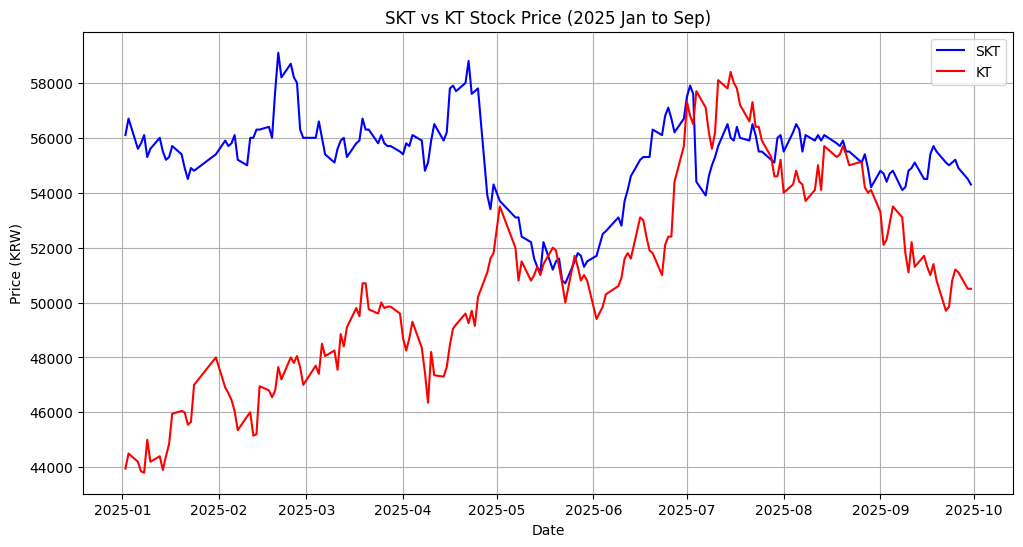

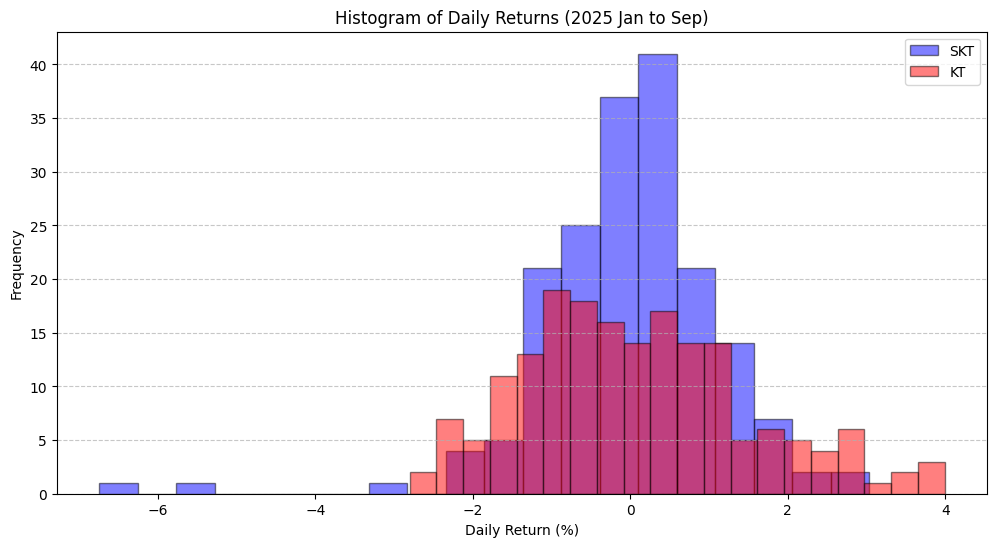

일별 수익률 상관관계
          SKT        KT
SKT  1.000000  0.092068
KT   0.092068  1.000000


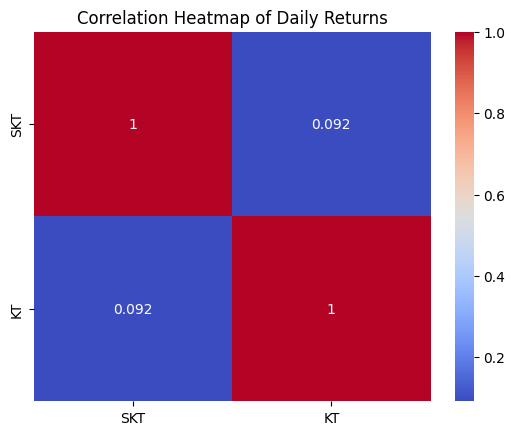

SKT 상승/하락일 분석
상승일: 87, 하락일: 95, 상승률: 47.80%, 하락률: 52.20%

KT 상승/하락일 분석
상승일: 84, 하락일: 98, 상승률: 46.15%, 하락률: 53.85%

SKT: 5일 중 3일 상승 확률 = 29.76%
KT: 5일 중 3일 상승 확률 = 28.51%


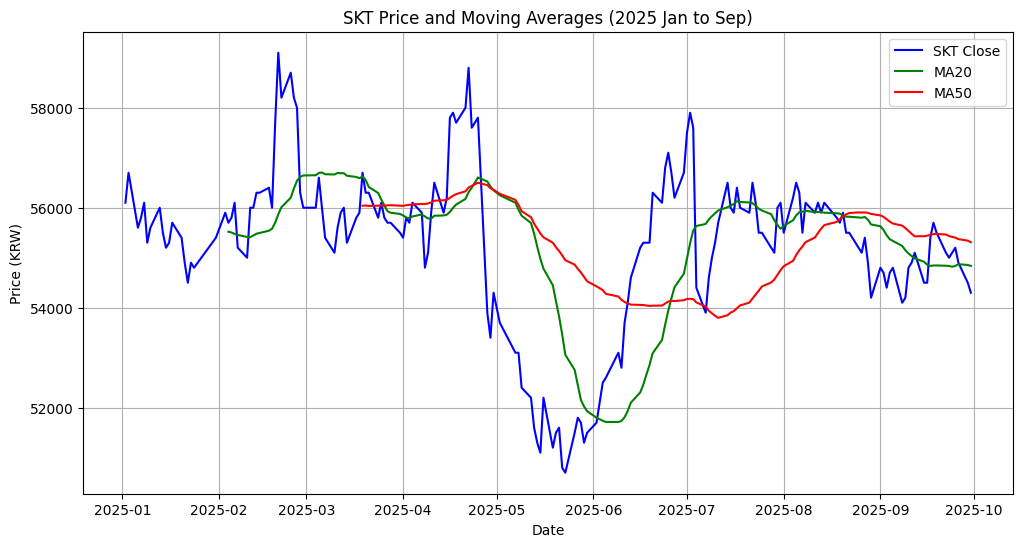

In [3]:
# SKT와 KT 2025년 1월 1일부터 9월 310일까지 데이터를 불러오고, 전처리, 시각화, 일별 수익률 계산, 상승/하락일 분석

# 1️⃣ 라이브러리 설치 및 불러오기
!pip install --upgrade finance-datareader

import FinanceDataReader as fdr
import pandas as pd
import matplotlib.pyplot as plt
import math
import seaborn as sns

# 2️⃣ 데이터 다운로드
skt_code = '017670'
kt_code  = '030200'
start_date = '2025-01-01'
end_date   = '2025-09-30'

df_skt = fdr.DataReader(skt_code, start_date, end_date)
df_kt  = fdr.DataReader(kt_code, start_date, end_date)

# 3️⃣ 기본 확인
print("SKT 데이터")
display(df_skt.head())
df_skt.info()

# KT 데이터
print("KT 데이터")
display(df_kt.head())
df_kt.info()

# 4️⃣ 컬럼명 통일 및 날짜 처리
df_skt.rename(columns={'Close':'Close', 'Open':'Open', 'Volume':'Volume'}, inplace=True)
df_kt.rename(columns={'Close':'Close', 'Open':'Open', 'Volume':'Volume'}, inplace=True)

df_skt.index = pd.to_datetime(df_skt.index)
df_kt.index  = pd.to_datetime(df_kt.index)

# 5️⃣ 주가 시각화 (비교)
plt.figure(figsize=(12,6))
plt.plot(df_skt['Close'], label='SKT', color='blue')
plt.plot(df_kt['Close'], label='KT', color='red')
plt.title('SKT vs KT Stock Price (2025 Jan to Sep)')
plt.xlabel('Date')
plt.ylabel('Price (KRW)')
plt.legend()
plt.grid(True)
plt.show()

# 6️⃣ 일별 수익률 계산
df_skt['daily_return'] = df_skt['Close'].pct_change()*100
df_kt['daily_return']  = df_kt['Close'].pct_change()*100

# 7️⃣ 일별 수익률 히스토그램
plt.figure(figsize=(12,6))
plt.hist(df_skt['daily_return'].dropna(), bins=20, alpha=0.5, label='SKT', color='blue', edgecolor='black')
plt.hist(df_kt['daily_return'].dropna(), bins=20, alpha=0.5, label='KT', color='red', edgecolor='black')
plt.title('Histogram of Daily Returns (2025 Jan to Sep)')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 8️⃣ 상관관계 확인
returns = pd.concat([df_skt['daily_return'], df_kt['daily_return']], axis=1)
returns.columns = ['SKT', 'KT']
correlation = returns.corr()
print("일별 수익률 상관관계")
print(correlation)

sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Daily Returns')
plt.show()

# 9️⃣ 상승/하락일 비율 계산
def up_down_analysis(df):
    r = df['daily_return'].dropna()
    positive = (r>0).sum()
    negative = (r<=0).sum()
    positive_rate = positive / len(r)
    negative_rate = 1 - positive_rate
    print(f"상승일: {positive}, 하락일: {negative}, 상승률: {positive_rate:.2%}, 하락률: {negative_rate:.2%}")
    return positive_rate, negative_rate

print("SKT 상승/하락일 분석")
skt_positive_rate, skt_negative_rate = up_down_analysis(df_skt)
print("\nKT 상승/하락일 분석")
kt_positive_rate, kt_negative_rate = up_down_analysis(df_kt)

# 🔟 예: 5일 중 3일 상승할 확률 계산
def prob_rise(positive_rate, days=5, rise_days=3):
    number = math.factorial(days) / (math.factorial(rise_days) * math.factorial(days-rise_days))
    prob = number * (positive_rate**rise_days) * ((1-positive_rate)**(days-rise_days))
    return prob

skt_prob = prob_rise(skt_positive_rate)
kt_prob  = prob_rise(kt_positive_rate)

print(f"\nSKT: 5일 중 3일 상승 확률 = {skt_prob:.2%}")
print(f"KT: 5일 중 3일 상승 확률 = {kt_prob:.2%}")

# 1️⃣1️⃣ 이동평균 시각화 (단기 vs 중기)
df_skt['MA20'] = df_skt['Close'].rolling(20).mean()
df_skt['MA50'] = df_skt['Close'].rolling(50).mean()

plt.figure(figsize=(12,6))
plt.plot(df_skt['Close'], label='SKT Close', color='blue')
plt.plot(df_skt['MA20'], label='MA20', color='green')
plt.plot(df_skt['MA50'], label='MA50', color='red')
plt.title('SKT Price and Moving Averages (2025 Jan to Sep)')
plt.xlabel('Date')
plt.ylabel('Price (KRW)')
plt.legend()
plt.grid(True)
plt.show()
